In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install pennylane-lightning[gpu]

In [ ]:
pip install imbalanced-learn

In [ ]:
!pip install pennylane #numpy pandas scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 80.2 MB/s eta 0:00:00


## Binary Classification based on CICIDS 2017 dataset

## Reading the Dataset

In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")

print("Path to dataset files:", path)

100%|██████████| 230M/230M [00:04<00:00, 54.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/chethuhn/network-intrusion-dataset/versions/1


In [ ]:
# Loading the dataset
data7 = pd.read_csv(os.path.join(path,'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'), engine='python', encoding='latin1')

In [ ]:
print('the shape is ',data7.shape)
print(' ******************* ')
label_counts = data7[' Label'].value_counts()
print("Distribution of classes: ",label_counts)

the shape is  (286467, 79)
 ******************* 
Distribution of classes:   Label
PortScan    158930
BENIGN      127537
Name: count, dtype: int64


# **Data 8**

In [ ]:
import pandas as pd

In [ ]:
data8 = pd.read_csv(os.path.join(path,'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'), engine='python', encoding='latin1')

In [ ]:
print('the shape is ',data8.shape)
print(' ******************* ')
label_counts = data8[' Label'].value_counts()
print("Distribution of classes: ",label_counts)

the shape is  (225745, 79)
 ******************* 
Distribution of classes:   Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


In [ ]:
data_list = [data8]

print('Data dimensions: ')
for i, data in enumerate(data_list, start = 1):
  rows, cols = data.shape
  print(f'Data{i} -> {rows} rows, {cols} columns')

Data dimensions: 
Data1 -> 225745 rows, 79 columns


# **Data Concatination**

In [ ]:
data = pd.concat(data_list)
rows, cols = data.shape

print('New dimension:')
print(f'Number of rows: {rows}')
print(f'Number of columns: {cols}')
print(f'Total cells: {rows * cols}')

New dimension:
Number of rows: 225745
Number of columns: 79
Total cells: 17833855


## Data Cleaning

In [ ]:
# Deleting dataframes after concating to save memory
for d in data_list: del d

In [ ]:
# Renaming the columns by removing leading/trailing whitespace
col_names = {col: col.strip() for col in data.columns}
data.rename(columns = col_names, inplace = True)

# Identifying duplicate values

In [ ]:
dups = data[data.duplicated()]
print(f'Number of duplicates: {len(dups)}')

Number of duplicates: 2633


In [ ]:
data.drop_duplicates(inplace = True)
data.shape

(223112, 79)

In [ ]:
# Replacing any infinite values (positive or negative) with NaN (not a number)
print(f'Initial missing values: {data.isna().sum().sum()}')

data.replace([np.inf, -np.inf], np.nan, inplace = True)

print(f'Missing values after processing infinite values: {data.isna().sum().sum()}')

Initial missing values: 4
Missing values after processing infinite values: 60


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
sns.set(style='darkgrid')
import matplotlib.pyplot as plt

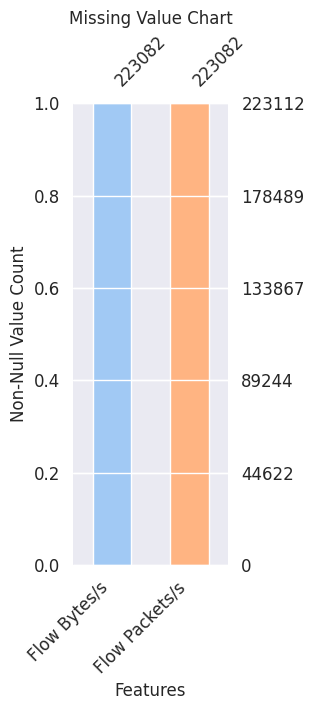

In [ ]:
sns.set_palette('pastel')
colors = sns.color_palette()

missing_vals = [col for col in data.columns if data[col].isna().any()]

fig, ax = plt.subplots(figsize = (2, 6))
msno.bar(data[missing_vals], ax = ax, fontsize = 12, color = colors)
ax.set_xlabel('Features', fontsize = 12)
ax.set_ylabel('Non-Null Value Count', fontsize = 12)
ax.set_title('Missing Value Chart', fontsize = 12)
plt.show()

# **Dealing with missing values (Columns with missing data)**

In [ ]:
med_flow_bytes = data['Flow Bytes/s'].median()
med_flow_packets = data['Flow Packets/s'].median()

print('Median of Flow Bytes/s: ', med_flow_bytes)
print('Median of Flow Packets/s: ', med_flow_packets)

Median of Flow Bytes/s:  930.8986575
Median of Flow Packets/s:  4.973057082


In [ ]:
# Filling missing values with median
data['Flow Bytes/s'].fillna(med_flow_bytes, inplace = True)
data['Flow Packets/s'].fillna(med_flow_packets, inplace = True)

/tmp/ipython-input-1818654804.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Flow Bytes/s'].fillna(med_flow_bytes, inplace = True)
/tmp/ipython-input-1818654804.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [ ]:
print('Number of \'Flow Bytes/s\' missing values:', data['Flow Bytes/s'].isna().sum())
print('Number of \'Flow Packets/s\' missing values:', data['Flow Packets/s'].isna().sum())

Number of 'Flow Bytes/s' missing values: 0
Number of 'Flow Packets/s' missing values: 0


# **Visualisation**

In [ ]:
# Creating a dictionary that maps each label to its attack type
attack_map = {
    'BENIGN': 'BENIGN',
    'DDoS': 'DDoS',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'PortScan': 'Port Scan',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Bot',
    'Web Attack � Brute Force': 'Web Attack',
    'Web Attack � XSS': 'Web Attack',
    'Web Attack � Sql Injection': 'Web Attack',
    'Infiltration': 'Infiltration',
    'Heartbleed': 'Heartbleed'
}

# Creating a new column 'Attack Type' in the DataFrame based on the attack_map dictionary
data['Attack Type'] = data['Label'].map(attack_map)

/tmp/ipython-input-323780027.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = 'Attack Type', data = attacks, palette = 'pastel', order = attacks['Attack Type'].value_counts().index)


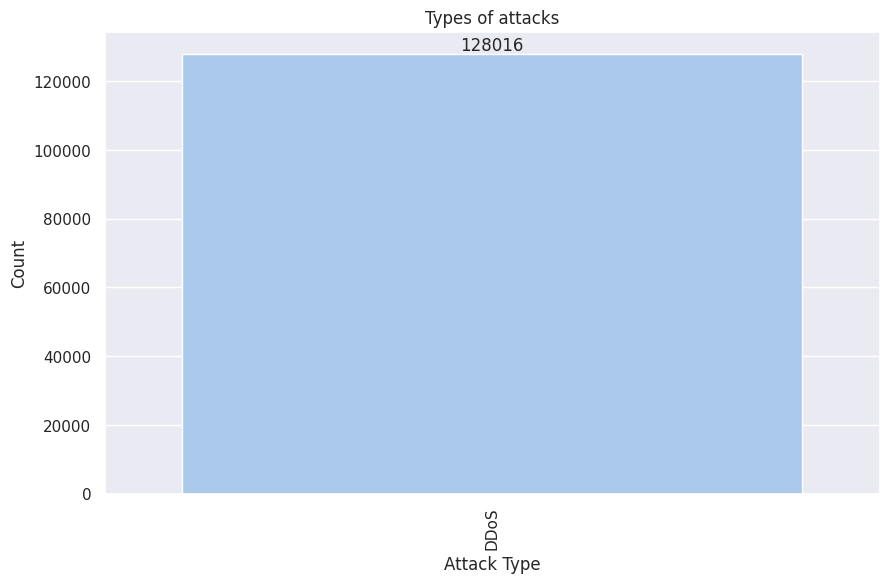

In [ ]:
# Different 'Attack Type' in the main dataset excluding 'BENIGN'
attacks = data.loc[data['Attack Type'] != 'BENIGN']

plt.figure(figsize = (10, 6))
ax = sns.countplot(x = 'Attack Type', data = attacks, palette = 'pastel', order = attacks['Attack Type'].value_counts().index)
plt.title('Types of attacks')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation = 90)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2, p.get_height() + 1000), ha = 'center')

plt.show()

## Attack Counts over Protocol Types

In [ ]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Set figure size
plt.figure(figsize=(16, 4))

# Create a count plot of attack types grouped by protocol type
sns.countplot(x='Label', data=data, hue=' Label')

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Set plot title
plt.title('Attack Counts over Protocol Types', fontdict={'fontsize': 16})

# Show the plot
plt.show()

ValueError: Could not interpret value ` Label` for `hue`. An entry with this name does not appear in `data`.

<Figure size 1600x400 with 0 Axes>


Class distribution:
Label
DDoS      128016
BENIGN     95096
Name: count, dtype: int64


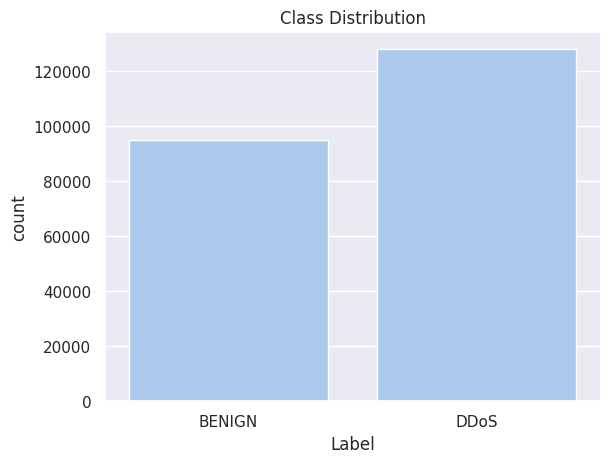

In [ ]:
import seaborn as sns

print("\nClass distribution:")
print(data['Label'].value_counts())

sns.countplot(x='Label', data=data)
plt.title("Class Distribution")
plt.show()

In [ ]:
# For improving performance and reduce memory-related errors
old_memory_usage = data.memory_usage().sum() / 1024 ** 2
print(f'Initial memory usage: {old_memory_usage:.2f} MB')
for col in data.columns:
    col_type = data[col].dtype
    if col_type != object:
        c_min = data[col].min()
        c_max = data[col].max()
        # Downcasting float64 to float32
        if str(col_type).find('float') >= 0 and c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
            data[col] = data[col].astype(np.float32)

        # Downcasting int64 to int32
        elif str(col_type).find('int') >= 0 and c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
            data[col] = data[col].astype(np.int32)

new_memory_usage = data.memory_usage().sum() / 1024 ** 2
print(f"Final memory usage: {new_memory_usage:.2f} MB")

Initial memory usage: 137.88 MB
Final memory usage: 71.49 MB


In [ ]:
# Dropping columns with only one unique value
num_unique = data.nunique()
one_variable = num_unique[num_unique == 1]
not_one_variable = num_unique[num_unique > 1].index

dropped_cols = one_variable.index
data = data[not_one_variable]

print('Dropped columns:')
dropped_cols

Dropped columns:


Index(['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count',
       'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate',
       'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate'],
      dtype='object')

In [ ]:
data.shape

(223112, 70)

In [ ]:
# Columns after removing non variant columns
data.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count'

In [ ]:
label_counts = data['Attack Type'].value_counts()
print("Distribution of classes: ",label_counts)

label_counts1 = data['Label'].value_counts()
print("Distribution of classes: ",label_counts1)

Distribution of classes:  Attack Type
DDoS      128016
BENIGN     95096
Name: count, dtype: int64
Distribution of classes:  Label
DDoS      128016
BENIGN     95096
Name: count, dtype: int64


In [ ]:
# Save the processed data to a CSV file
data.to_csv('/content/drive/MyDrive/phd3/cicids2017_Code/CICIDS_2017_DDOS.csv', index=False)
print("Data saved to dataset.csv")

Data saved to dataset.csv


# **Loading the NEW dataset**

In [ ]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt
%matplotlib inline
import os
                    #'/content/drive/MyDrive/phd3/cicids2017_Code/CICIDS_2017_DDOS.csv
data = pd.read_csv('/content/drive/MyDrive/phd3/cicids2017_Code/Cicids_2017_DDOS/CICIDS_2017_DDOS.csv')

# **Im going to classify based on Attacks type not Lables**

In [ ]:
data.drop('Label', axis = 1, inplace = True)

In [ ]:
# For improving performance and reduce memory-related errors
old_memory_usage = data.memory_usage().sum() / 1024 ** 2
print(f'Initial memory usage: {old_memory_usage:.2f} MB')
for col in data.columns:
    col_type = data[col].dtype
    if col_type != object:
        c_min = data[col].min()
        c_max = data[col].max()
        # Downcasting float64 to float32
        if str(col_type).find('float') >= 0 and c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
            data[col] = data[col].astype(np.float32)

        # Downcasting int64 to int32
        elif str(col_type).find('int') >= 0 and c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
            data[col] = data[col].astype(np.int32)

new_memory_usage = data.memory_usage().sum() / 1024 ** 2
print(f"Final memory usage: {new_memory_usage:.2f} MB")

Initial memory usage: 117.45 MB
Final memory usage: 59.58 MB


In [ ]:
# Dropping columns with only one unique value
num_unique = data.nunique()
one_variable = num_unique[num_unique == 1]
not_one_variable = num_unique[num_unique > 1].index

dropped_cols = one_variable.index
data = data[not_one_variable]

print('Dropped columns:')
dropped_cols

Dropped columns:


Index([], dtype='object')

# **Binary Classes**

In [ ]:
data['Attack Type'] = data['Attack Type'].apply(lambda x: 'normal' if x == 'BENIGN' else 'attack')

In [ ]:
data['Attack Type'].value_counts()

,count
Attack Type,
DDoS,128016
BENIGN,95096


In [ ]:
new_data = data

In [ ]:
# Creating a balanced dataset for Binary Classification
#new_data = data
normal_traffic = new_data.loc[new_data['Attack Type'] == 'normal']
intrusions = new_data.loc[new_data['Attack Type'] == 'attack']

normal_traffic = normal_traffic.sample(n = len(intrusions), replace = True,random_state = 42)

ids_data = pd.concat([intrusions, normal_traffic])
ids_data['Attack Type'] = np.where((ids_data['Attack Type'] == 'normal'), 0, 1)
bc_data = ids_data.sample(n = 25000)

print(bc_data['Attack Type'].value_counts())

Attack Type
1    12502
0    12498
Name: count, dtype: int64


## split data to X and Y

In [ ]:
# Séparation des caractéristiques et de la cible
X = bc_data.drop('Attack Type', axis=1)
# Convert the attack column to binary labels: 'normal' or 'attack'
y = bc_data['Attack Type']

In [ ]:
y.value_counts()

,count
Attack Type,
0,12552
1,12448


In [ ]:
y.head()

,Attack Type
13582,0
30684,0
189204,1
195200,1
122455,1


In [ ]:
print("Unique values in 'Attack Type' after mapping:")
print(bc_data['Attack Type'].unique())
print("\nValue counts in 'Attack Type' after mapping:")
print(bc_data['Attack Type'].value_counts())

Unique values in 'Attack Type' after mapping:
[1 0]

Value counts in 'Attack Type' after mapping:
Attack Type
0    12507
1    12493
Name: count, dtype: int64


## Pytorch

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

import pennylane as qml
from pennylane.qnn import TorchLayer

/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


In [ ]:
from sklearn.preprocessing import StandardScaler
# Normalisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# 🔤 Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y) # 0 = attack , 1 = normal
#y_bin_encoded = label_encoder.fit_transform(y_binary)


Class distribution:
Attack Type
normal    2096484
attack     425878
Name: count, dtype: int64


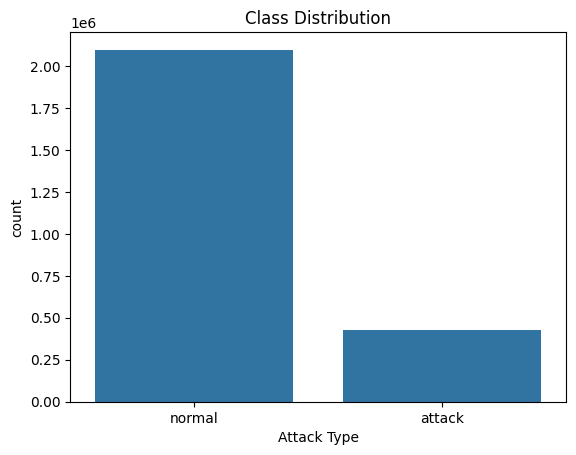

In [ ]:
import seaborn as sns

print("\nClass distribution:")
print(bc_data['Attack Type'].value_counts())

sns.countplot(x='Attack Type', data=bc_data)
plt.title("Class Distribution")
plt.show()


Class distribution:
Attack Type
0    12512
1    12488
Name: count, dtype: int64


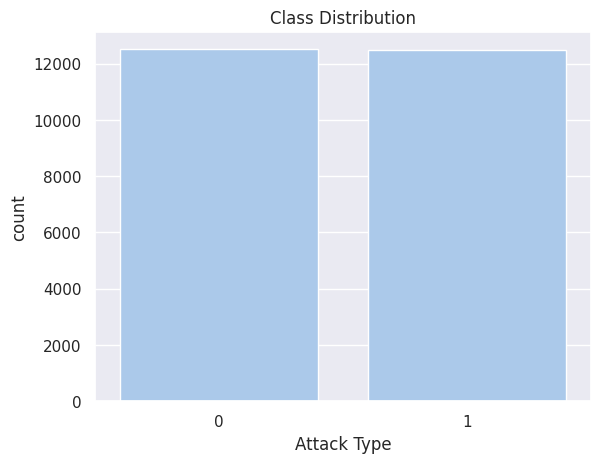

In [ ]:
import seaborn as sns

print("\nClass distribution:")
print(bc_data['Attack Type'].value_counts())

sns.countplot(x='Attack Type', data=bc_data)
plt.title("Class Distribution")
plt.show()

## **SMOTE is optional**

In [ ]:
# 🔄 SMOTE (optional but common for IDS datasets)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y_encoded)

# 🔢 Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

# **QRL**

# **3rd version with real Cicids2017 Dataset**

In [ ]:
"""
qrl_ids_pipeline.py
Complete demo pipeline for QRL-IDS:
- Synthetic dataset (placeholder for CICIDS2017)
- StandardScaler -> PCA to n_qubits dims
- Gym-like streaming environment with reward shaping
- Classical REINFORCE baseline (PyTorch)
- Hybrid QNN policy (PennyLane + TorchLayer)
- Train both and save results for analysis

Replace the synthetic dataset with your CICIDS2017 preprocessing
if you want to run on real data (see comments).
"""

import os
import numpy as np
import random
import pickle
import argparse
from collections import deque
import time # Corrected import statement
import torch
import torch.nn as nn
import torch.optim as optim

# try/except to give a nice message if PennyLane isn't installed
try:
    import pennylane as qml
    from pennylane.qnn import TorchLayer
except Exception as e:
    qml = None
    TorchLayer = None
    print("Warning: PennyLane not found. Hybrid QNN will not run unless you install pennylane.")
    print("Install with: pip install pennylane")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
# -------------------------
# Config / Hyperparameters
# -------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

N_SAMPLES = 25000
ORIG_DIMS = 30
N_QUBITS = 2
N_ACTIONS = 2  # 0 = ignore (benign), 1 = alert (attack)
EPISODE_LENGTH = 200
TRAIN_EPISODES = 1000
GAMMA = 0.99
LR = 1e-3
N_LAYERS_QNN = 2  # ansatz depth for QNN

OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/cicids2017_Results/AngleEmbedding/IQP-pca2-DDos/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
# -------------------------
# Utility functions
# -------------------------
def generate_synthetic_dataset(n_samples=5000, orig_dims=30, attack_ratio=0.18):
    n_attack = int(n_samples * attack_ratio)
    n_benign = n_samples - n_attack
    benign = np.random.normal(loc=0.0, scale=1.0, size=(n_benign, orig_dims))
    attack = np.random.normal(loc=1.5, scale=1.2, size=(n_attack, orig_dims))
    X = np.vstack([benign, attack])
    y = np.hstack([np.zeros(n_benign, dtype=int), np.ones(n_attack, dtype=int)])
    idx = np.arange(n_samples)
    np.random.shuffle(idx)
    return X[idx], y[idx]

def compute_metrics(true_labels, pred_labels):
    acc = accuracy_score(true_labels, pred_labels)
    p, r, f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average='binary', zero_division=0)
    cm = confusion_matrix(true_labels, pred_labels)
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1, "confusion_matrix": cm}

In [ ]:
# -------------------------
# Env: Gym-like streaming
# -------------------------
class IDSStreamEnv:
    def __init__(self, X, y, episode_length=200, shuffle=True, seed=None):
        self.X = X
        self.y = y
        self.n = len(X)
        self.episode_length = episode_length
        self.shuffle = shuffle
        self.rng = np.random.RandomState(seed)
        self.order = np.arange(self.n)
        if self.shuffle:
            self.rng.shuffle(self.order)
        self.reset()

    def reset(self):
        start = self.rng.randint(0, max(1, self.n - self.episode_length))
        self.cur_idx = start
        self.steps = 0
        state = self.X[self.order[self.cur_idx]]
        return state.astype(np.float32)

    def step(self, action):
        label = self.y[self.order[self.cur_idx]]
        # reward shaping (tune these numbers to your needs)
        if action == 1 and label == 1:  # true positive
            reward = 2.0
        elif action == 0 and label == 1:  # false negative (miss)
            reward = -2.0
        elif action == 1 and label == 0:  # false positive
            reward = -0.5
        else:  # action == 0 and label == 0 (true negative)
            reward = 2.0
        self.cur_idx += 1
        self.steps += 1
        done = self.steps >= self.episode_length or self.cur_idx >= self.n
        if not done:
            next_state = self.X[self.order[self.cur_idx]].astype(np.float32)
        else:
            next_state = np.zeros_like(self.X[0], dtype=np.float32)
        return next_state, float(reward), done, {"label": int(label)}

In [ ]:
# -------------------------
# Policies
# -------------------------
class ClassicalPolicy(nn.Module):
    def __init__(self, input_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions)
        )

    def forward(self, x):
        logits = self.net(x)
        return torch.softmax(logits, dim=-1)

def build_hybrid_policy(n_qubits, n_actions, n_layers=2):
    if qml is None:
        raise RuntimeError("PennyLane is required to build hybrid policy. pip install pennylane.")
    dev = qml.device("default.qubit", wires=n_qubits, shots=None)
    def qnode(inputs, weights):
        qml.templates.IQPEmbedding(inputs, wires=range(n_qubits))
        qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits))
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    weight_shapes = {"weights": (n_layers, n_qubits, 3)}
    #qnode_torch = qml.QNode(qnode, dev, interface='torch', diff_method='parameter-shift')
    qnode_torch = qml.QNode(qnode, dev, interface='torch', diff_method='backprop')

    qlayer = TorchLayer(qnode_torch, weight_shapes)

    class HybridPolicy(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc_in = nn.Linear(n_qubits, n_qubits)
            self.ql = qlayer
            self.fc_out = nn.Sequential(
                nn.Linear(n_qubits, 32),
                nn.Tanh(),
                nn.Linear(32, n_actions)
            )
        def forward(self, x):
            x = torch.tanh(self.fc_in(x))
            x = self.ql(x)
            logits = self.fc_out(x)
            return torch.softmax(logits, dim=-1)
    return HybridPolicy()

In [ ]:
# -------------------------
# REINFORCE training routine
# -------------------------
def reinforce_train(env, policy, optimizer, episodes=100, max_steps=200, gamma=0.99, name="policy"):
    import time # Ensure time module is correctly imported within function scope
    all_episode_rewards = []
    metrics_history = []
    for ep in range(episodes):
        start_time = time.time()  # Start time for the episode
        log_probs = []
        rewards = []
        labels = []
        preds = []
        state = env.reset()
        for t in range(max_steps):
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
            probs = policy(state_tensor).squeeze(0)
            m = torch.distributions.Categorical(probs)
            action = m.sample()
            log_prob = m.log_prob(action)
            next_state, reward, done, info = env.step(int(action.item()))
            log_probs.append(log_prob)
            rewards.append(reward)
            labels.append(info["label"])
            preds.append(int(action.item()))
            state = next_state
            if done:
                break
        # compute discounted returns
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.tensor(returns, dtype=torch.float32)
        if returns.size(0) > 1 and returns.std().item() > 1e-8:
            returns = (returns - returns.mean()) / (returns.std() + 1e-9)
        loss = 0
        for log_prob, Gt in zip(log_probs, returns):
            loss -= log_prob * Gt
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_reward = sum(rewards)
        all_episode_rewards.append(total_reward)
        metrics = compute_metrics(np.array(labels), np.array(preds))
        metrics_history.append(metrics)
        end_time = time.time()  # End time for the episode
        episode_duration = end_time - start_time
        if (ep + 1) % 10 == 0 or ep == 0:
            print(f"[{name}] Episode {ep+1}/{episodes}  Reward: {total_reward:.2f}  Acc: {metrics['accuracy']:.3f}  F1: {metrics['f1']:.3f}  Time: {episode_duration:.2f}s")
    return all_episode_rewards, metrics_history

# **new version + FN Score and test samples**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np
import os, pickle, matplotlib.pyplot as plt
import torch.optim as optim
pi = np.pi

# -------------------------
# Main pipeline (synthetic or CICIDS)
# -------------------------
def main():
    # 1) Load or generate data
    # X, y = generate_synthetic_dataset(N_SAMPLES, ORIG_DIMS, attack_ratio=0.18)

    # Example with CICIDS dataset:
    # df = pd.read_csv("data/cicids_combined.csv")
    # df = df.dropna()
    # numeric_cols = [c for c in df.columns if df[c].dtype != 'object']
    # X = df[numeric_cols].values
    # y = (df["Label"] != "BENIGN").astype(int).values

    print("Data shapes:", X.shape, y.shape, "Attack ratio:", y_encoded.mean())


    pca = PCA(n_components=N_QUBITS)
    X_pca = pca.fit_transform(X_scaled)
    print("PCA shape:", X_pca.shape)

    # Normalize PCA output to [0, 2π] for angle embedding
    #X_min, X_max = X_pca.min(), X_pca.max()
    #X_pca_scaled = 2 * pi * (X_pca - X_min) / (X_max - X_min)

    # 3) Split into train/test sets for classical
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y_encoded, test_size=0.2, random_state=42, stratify=y)
    print(f"Train: {X_train.shape}, Test: {X_test.shape}")

    # 4) Build separate environments
    env_train_classical = IDSStreamEnv(X_train, y_train, episode_length=EPISODE_LENGTH, shuffle=True, seed=1)
    env_train_hybrid = IDSStreamEnv(X_train, y_train, episode_length=EPISODE_LENGTH, shuffle=True, seed=2)
    env_test_classical = IDSStreamEnv(X_test, y_test, episode_length=len(X_test), shuffle=False)
    env_test_hybrid = IDSStreamEnv(X_test, y_test, episode_length=len(X_test), shuffle=False)

    # 5) Classical REINFORCE
    classical_policy = ClassicalPolicy(N_QUBITS, N_ACTIONS)
    optimizer_c = optim.Adam(classical_policy.parameters(), lr=LR)
    print("Training classical REINFORCE baseline...")
    start_time_classical = time.time()

    rewards_classical, metrics_classical = reinforce_train(
        env_train_classical, classical_policy, optimizer_c,
        episodes=TRAIN_EPISODES, max_steps=EPISODE_LENGTH, gamma=GAMMA, name="Classical"
    )

    end_time_classical = time.time()
    classical_training_time = end_time_classical - start_time_classical
    print(f"Classical training time: {classical_training_time:.3f} seconds")

    # 6) Hybrid Quantum Neural Network REINFORCE
    if qml is None:
        print("Skipping hybrid QNN training because PennyLane is not installed.")
        rewards_hybrid, metrics_hybrid = [], []
    else:
        hybrid_policy = build_hybrid_policy(N_QUBITS, N_ACTIONS, n_layers=N_LAYERS_QNN)
        optimizer_h = optim.Adam(hybrid_policy.parameters(), lr=LR)
        #weights = opt.step(weights, batch_x, batch_y)
        print("Training hybrid QNN REINFORCE policy...")
        start_time_hybrid = time.time()

        rewards_hybrid, metrics_hybrid = reinforce_train(
            env_train_hybrid, hybrid_policy, optimizer_h,
            episodes=TRAIN_EPISODES, max_steps=EPISODE_LENGTH, gamma=GAMMA, name="Hybrid-QNN"
        )

        end_time_hybrid = time.time()
        hybrid_training_time = end_time_hybrid - start_time_hybrid
        print(f"Hybrid QNN training time: {hybrid_training_time:.3f} seconds")

    # 7) Evaluate on test set
    def evaluate_model(env, policy, name):
        all_preds, all_true = [], []
        for X_batch, y_batch in zip(env.X, env.y):
            X_tensor = torch.tensor(X_batch, dtype=torch.float32)
            with torch.no_grad():
                probs = policy(X_tensor)
            pred = torch.argmax(probs).item()
            all_preds.append(pred)
            all_true.append(int(y_batch))

        acc = accuracy_score(all_true, all_preds)
        prec = precision_score(all_true, all_preds, zero_division=0)
        rec = recall_score(all_true, all_preds, zero_division=0)
        f1 = f1_score(all_true, all_preds, zero_division=0)
        cm = confusion_matrix(all_true, all_preds)
        tn, fp, fn, tp = cm.ravel()
        #tnr = tn / (tn + fp)
        #fpr = fp / (fp + tn)
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0      # False Positive Rate
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0      # False Negative Rate

        metrics = {
            "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

        print(f"{name} Test Metrics: {metrics}")

        metrics = {
            "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
            "false_negative_rate": fnr, "false_positive_rate": fpr,"confusion_matrix": cm
        }
        return metrics

    metrics_test_classical = evaluate_model(env_test_classical, classical_policy, "Classical")
    metrics_test_hybrid = evaluate_model(env_test_hybrid, hybrid_policy, "Hybrid-QNN") if len(metrics_hybrid) > 0 else {}

    # Save the trained hybrid QNN policy
    torch.save(hybrid_policy.state_dict(), "/content/drive/MyDrive/phd3/outputs/cicids2017_Results/IQPEmbedding/hybrid_nsl_trained.pt")
    print("✅ Saved hybrid QNN pretrained weights")

    # 8) Save results
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    results = {
        "rewards_classical": rewards_classical,
        "metrics_classical": metrics_classical,
        "rewards_hybrid": rewards_hybrid,
        "metrics_hybrid": metrics_hybrid,
        "test_classical": metrics_test_classical,
        "test_hybrid": metrics_test_hybrid,
        "scaler": scaler,
        "pca": pca
    }
    with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "wb") as f:
        pickle.dump(results, f)
    print(f"Saved results to {OUTPUT_DIR}/qrl_ids_results.pkl")

    # 9) Save metrics to CSV
    df_classical = pd.DataFrame(metrics_classical)
    df_hybrid = pd.DataFrame(metrics_hybrid)
    df_classical.to_csv(os.path.join(OUTPUT_DIR, "train_metrics_classical.csv"), index=False)
    if len(metrics_hybrid) > 0:
        df_hybrid.to_csv(os.path.join(OUTPUT_DIR, "train_metrics_hybrid.csv"), index=False)

    pd.DataFrame([metrics_test_classical]).to_csv(os.path.join(OUTPUT_DIR, "test_metrics_classical.csv"), index=False)
    if len(metrics_test_hybrid) > 0:
        pd.DataFrame([metrics_test_hybrid]).to_csv(os.path.join(OUTPUT_DIR, "test_metrics_hybrid.csv"), index=False)

    print("Saved metrics CSVs to", OUTPUT_DIR)

    # 10) Reward and performance plots
    plt.figure(figsize=(8,4))
    if len(rewards_classical) > 0:
        plt.plot(rewards_classical, label="Classical (REINFORCE)")
    if len(rewards_hybrid) > 0:
        plt.plot(rewards_hybrid, label="Hybrid QNN (REINFORCE)")
    plt.title("Episode Rewards")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "rewards_curve.png"))
    plt.close()

    def plot_metric(metric_name, classical_metrics, hybrid_metrics, save_path):
        plt.figure(figsize=(8,4))
        plt.plot([m[metric_name] for m in classical_metrics], label="Classical", color='blue')
        if len(hybrid_metrics) > 0:
            plt.plot([m[metric_name] for m in hybrid_metrics], label="Hybrid QNN", color='orange')
        plt.title(f"{metric_name.capitalize()} over Episodes")
        plt.xlabel("Episode"); plt.ylabel(metric_name.capitalize())
        plt.legend(); plt.grid(True); plt.tight_layout()
        plt.savefig(save_path); plt.close()

    plot_metric("accuracy", metrics_classical, metrics_hybrid, os.path.join(OUTPUT_DIR, "accuracy_curve.png"))
    plot_metric("f1", metrics_classical, metrics_hybrid, os.path.join(OUTPUT_DIR, "f1_curve.png"))

    def plot_confusion_matrix(cm, title, save_path):
        plt.figure(figsize=(4,4))
        plt.imshow(cm, cmap='Blues')
        plt.title(title)
        plt.colorbar()
        plt.xticks([0,1], ['Benign','Attack'])
        plt.yticks([0,1], ['Benign','Attack'])
        for i in range(2):
            for j in range(2):
                plt.text(j, i, cm[i,j], ha='center', va='center', color='black', fontsize=12)
        plt.tight_layout()
        plt.savefig(save_path)
        plt.close()

    plot_confusion_matrix(metrics_test_classical["confusion_matrix"], "Classical Test Confusion Matrix", os.path.join(OUTPUT_DIR, "cm_test_classical.png"))
    if len(metrics_test_hybrid) > 0:
        plot_confusion_matrix(metrics_test_hybrid["confusion_matrix"], "Hybrid QNN Test Confusion Matrix", os.path.join(OUTPUT_DIR, "cm_test_hybrid.png"))

    print(f"\n✅ Training and evaluation complete! Results and plots saved in {OUTPUT_DIR}\n")


# **PCA 2**

In [ ]:
if __name__ == "__main__":
    main()

Data shapes: (25000, 68) (25000,) Attack ratio: 0.49792
PCA shape: (25000, 2)
Train: (20000, 2), Test: (5000, 2)
Training classical REINFORCE baseline...
[Classical] Episode 1/1000  Reward: 81.00  Acc: 0.515  F1: 0.503  Time: 0.29s
[Classical] Episode 10/1000  Reward: 102.00  Acc: 0.515  F1: 0.522  Time: 0.20s
[Classical] Episode 20/1000  Reward: 107.50  Acc: 0.505  F1: 0.512  Time: 0.21s
[Classical] Episode 30/1000  Reward: 139.50  Acc: 0.575  F1: 0.635  Time: 0.19s
[Classical] Episode 40/1000  Reward: 146.50  Acc: 0.580  F1: 0.635  Time: 0.19s
[Classical] Episode 50/1000  Reward: 136.00  Acc: 0.580  F1: 0.604  Time: 0.27s
[Classical] Episode 60/1000  Reward: 116.50  Acc: 0.550  F1: 0.598  Time: 0.20s
[Classical] Episode 70/1000  Reward: 170.00  Acc: 0.630  F1: 0.670  Time: 0.20s
[Classical] Episode 80/1000  Reward: 116.50  Acc: 0.535  F1: 0.559  Time: 0.21s
[Classical] Episode 90/1000  Reward: 151.50  Acc: 0.605  F1: 0.658  Time: 0.20s
[Classical] Episode 100/1000  Reward: 200.00  Ac

Loaded 1000 classical episodes and 1000 hybrid episodes.
✅ Saved FPR/FNR per episode to: /content/drive/MyDrive/phd3/outputs/cicids2017_Results/AngleEmbedding/IQP-pca2-DDos/fpr_fnr_per_episode.csv


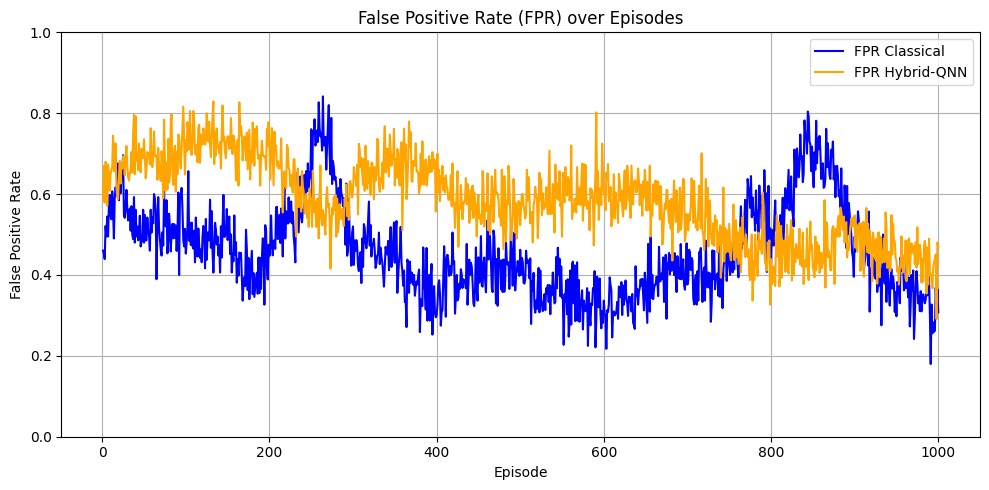

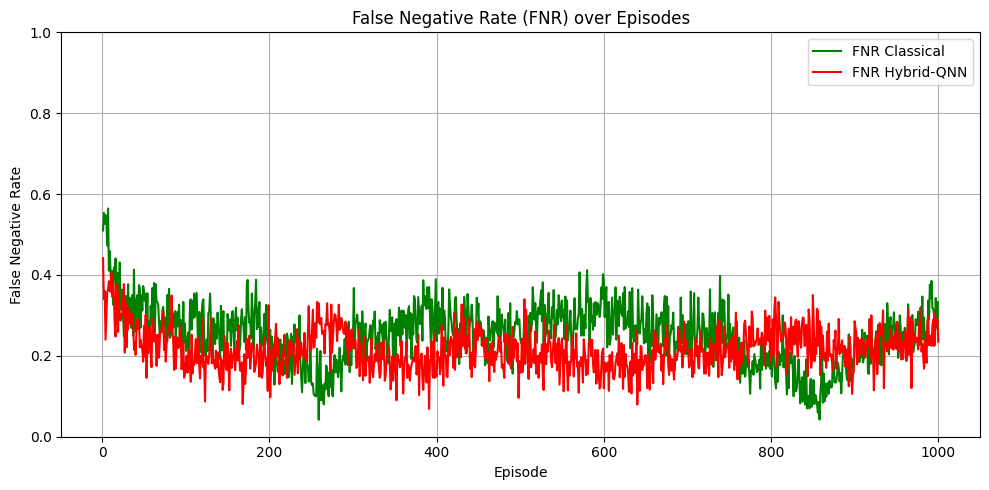

✅ FPR/FNR curves plotted and saved to output directory.


In [ ]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# 1️⃣ Load the results file
# =====================I
OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/cicids2017_Results/AngleEmbedding/IQP-pca2-DDos/"
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)

metrics_classical = results.get("metrics_classical", [])
metrics_hybrid = results.get("metrics_hybrid", [])

print(f"Loaded {len(metrics_classical)} classical episodes and {len(metrics_hybrid)} hybrid episodes.")

# =====================
# 2️⃣ Compute FPR & FNR for each episode
# =====================
def compute_fpr_fnr(metrics):
    fpr_list, fnr_list = [], []
    for i, m in enumerate(metrics):
        #print(f"Processing episode {i+1}/{len(metrics)}")
        #print("i:", i,"m:",m)
        cm = m.get("confusion_matrix")
        if cm is None or len(cm) != 2:
            fpr_list.append(None)
            fnr_list.append(None)
            continue
        tn, fp, fn, tp = cm.ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        fpr_list.append(fpr)
        fnr_list.append(fnr)
        # Optionally, update the dictionary
        #m["false_positive_rate"] = fpr
        #m["false_negative_rate"] = fnr
    return fpr_list, fnr_list

fpr_classical, fnr_classical = compute_fpr_fnr(metrics_classical)
fpr_hybrid, fnr_hybrid = compute_fpr_fnr(metrics_hybrid)

# =====================
# 3️⃣ Save to CSV
# =====================
df = pd.DataFrame({
    "Episode": range(1, len(fpr_classical) + 1),
    "FPR_Classical": fpr_classical,
    "FNR_Classical": fnr_classical,
    "FPR_Hybrid": fpr_hybrid[:len(fpr_classical)] if metrics_hybrid else None,
    "FNR_Hybrid": fnr_hybrid[:len(fnr_classical)] if metrics_hybrid else None
})

csv_path = os.path.join(OUTPUT_DIR, "fpr_fnr_per_episode.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Saved FPR/FNR per episode to: {csv_path}")

# =====================
# 4️⃣ Plot FPR & FNR curves
# =====================
plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FPR_Classical"], label="FPR Classical", color="blue")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FPR_Hybrid"], label="FPR Hybrid-QNN", color="orange")
plt.title("False Positive Rate (FPR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Positive Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fpr_curve.png"))
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FNR_Classical"], label="FNR Classical", color="green")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FNR_Hybrid"], label="FNR Hybrid-QNN", color="red")
plt.title("False Negative Rate (FNR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Negative Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fnr_curve.png"))
plt.show()

print("✅ FPR/FNR curves plotted and saved to output directory.")


# PCA 4

In [ ]:
# -------------------------
# Config / Hyperparameters
# -------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

N_SAMPLES = 45000
ORIG_DIMS = 30
N_QUBITS = 4
N_ACTIONS = 2  # 0 = ignore (benign), 1 = alert (attack)
EPISODE_LENGTH = 200
TRAIN_EPISODES = 1000
GAMMA = 0.99
LR = 1e-3
N_LAYERS_QNN = 2  # ansatz depth for QNN

OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/cicids2017_Results/IQPEmbedding/IQP-pca4-DDos/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
if __name__ == "__main__":
    main()

Data shapes: (25000, 68) (25000,) Attack ratio: 0.4994
PCA shape: (25000, 4)
Train: (20000, 4), Test: (5000, 4)
Training classical REINFORCE baseline...
[Classical] Episode 1/1000  Reward: 74.00  Acc: 0.495  F1: 0.502  Time: 0.53s
[Classical] Episode 10/1000  Reward: 96.00  Acc: 0.530  F1: 0.489  Time: 0.33s
[Classical] Episode 20/1000  Reward: 120.50  Acc: 0.540  F1: 0.516  Time: 0.34s
[Classical] Episode 30/1000  Reward: 143.50  Acc: 0.580  F1: 0.641  Time: 0.31s
[Classical] Episode 40/1000  Reward: 146.00  Acc: 0.585  F1: 0.631  Time: 0.21s
[Classical] Episode 50/1000  Reward: 162.50  Acc: 0.615  F1: 0.645  Time: 0.21s
[Classical] Episode 60/1000  Reward: 139.50  Acc: 0.590  F1: 0.627  Time: 0.20s
[Classical] Episode 70/1000  Reward: 162.50  Acc: 0.615  F1: 0.661  Time: 0.22s
[Classical] Episode 80/1000  Reward: 191.50  Acc: 0.640  F1: 0.673  Time: 0.23s
[Classical] Episode 90/1000  Reward: 217.50  Acc: 0.680  F1: 0.748  Time: 0.25s
[Classical] Episode 100/1000  Reward: 173.50  Acc:

Loaded 1000 classical episodes and 1000 hybrid episodes.
✅ Saved FPR/FNR per episode to: /content/drive/MyDrive/phd3/outputs/cicids2017_Results/IQPEmbedding/IQP-pca4-DDos/fpr_fnr_per_episode.csv


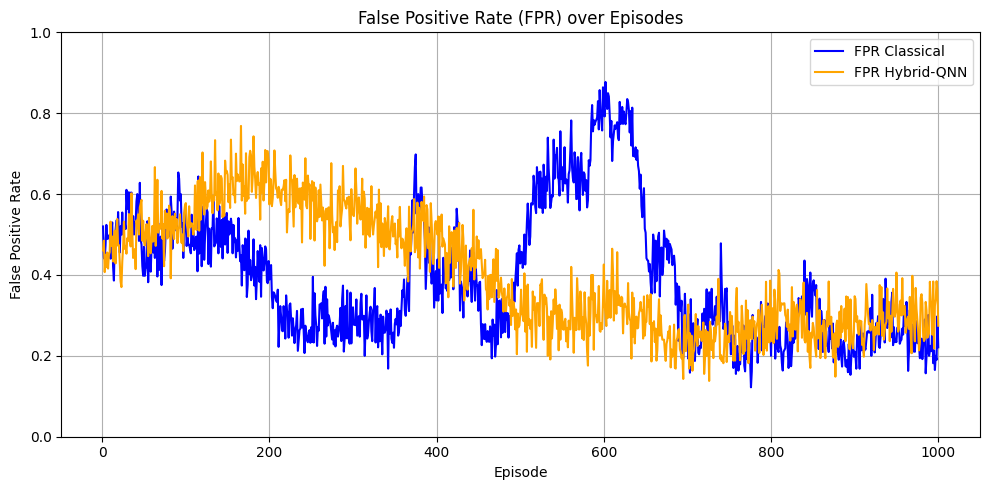

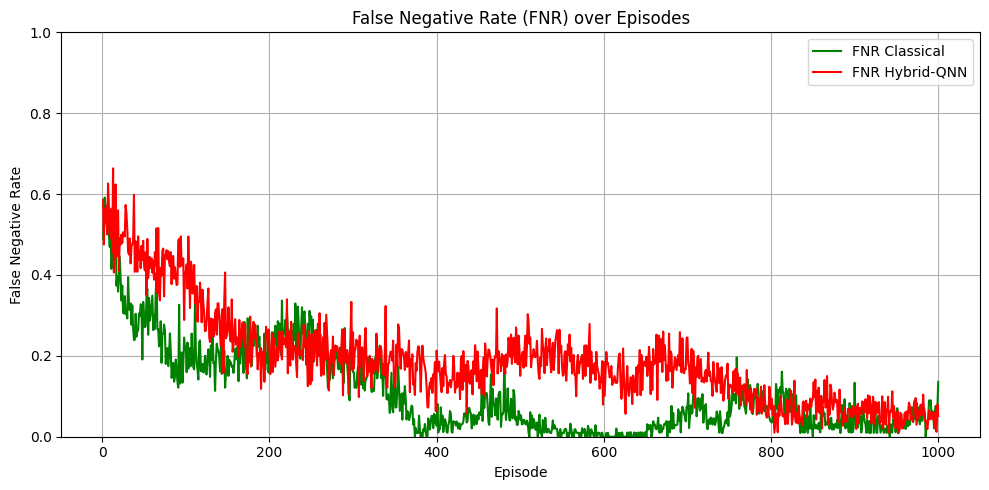

✅ FPR/FNR curves plotted and saved to output directory.


In [ ]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# 1️⃣ Load the results file
# =====================
OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/cicids2017_Results/IQPEmbedding/IQP-pca4-DDos/"
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)

metrics_classical = results.get("metrics_classical", [])
metrics_hybrid = results.get("metrics_hybrid", [])

print(f"Loaded {len(metrics_classical)} classical episodes and {len(metrics_hybrid)} hybrid episodes.")

# =====================
# 2️⃣ Compute FPR & FNR for each episode
# =====================
def compute_fpr_fnr(metrics):
    fpr_list, fnr_list = [], []
    for i, m in enumerate(metrics):
        #print(f"Processing episode {i+1}/{len(metrics)}")
        #print("i:", i,"m:",m)
        cm = m.get("confusion_matrix")
        if cm is None or len(cm) != 2:
            fpr_list.append(None)
            fnr_list.append(None)
            continue
        tn, fp, fn, tp = cm.ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        fpr_list.append(fpr)
        fnr_list.append(fnr)
        # Optionally, update the dictionary
        #m["false_positive_rate"] = fpr
        #m["false_negative_rate"] = fnr
    return fpr_list, fnr_list

fpr_classical, fnr_classical = compute_fpr_fnr(metrics_classical)
fpr_hybrid, fnr_hybrid = compute_fpr_fnr(metrics_hybrid)

# =====================
# 3️⃣ Save to CSV
# =====================
df = pd.DataFrame({
    "Episode": range(1, len(fpr_classical) + 1),
    "FPR_Classical": fpr_classical,
    "FNR_Classical": fnr_classical,
    "FPR_Hybrid": fpr_hybrid[:len(fpr_classical)] if metrics_hybrid else None,
    "FNR_Hybrid": fnr_hybrid[:len(fnr_classical)] if metrics_hybrid else None
})

csv_path = os.path.join(OUTPUT_DIR, "fpr_fnr_per_episode.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Saved FPR/FNR per episode to: {csv_path}")

# =====================
# 4️⃣ Plot FPR & FNR curves
# =====================
plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FPR_Classical"], label="FPR Classical", color="blue")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FPR_Hybrid"], label="FPR Hybrid-QNN", color="orange")
plt.title("False Positive Rate (FPR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Positive Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fpr_curve.png"))
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FNR_Classical"], label="FNR Classical", color="green")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FNR_Hybrid"], label="FNR Hybrid-QNN", color="red")
plt.title("False Negative Rate (FNR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Negative Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fnr_curve.png"))
plt.show()

print("✅ FPR/FNR curves plotted and saved to output directory.")


# **PCA 6**

In [ ]:
# -------------------------
# Config / Hyperparameters
# -------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

N_SAMPLES = 45000
ORIG_DIMS = 30
N_QUBITS = 6
N_ACTIONS = 2  # 0 = ignore (benign), 1 = alert (attack)
EPISODE_LENGTH = 200
TRAIN_EPISODES = 1000
GAMMA = 0.99
LR = 1e-3
N_LAYERS_QNN = 2  # ansatz depth for QNN

OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/cicids2017_Results/IQPEmbedding/IQP-pca6-DDos/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
if __name__ == "__main__":
    main()

Data shapes: (25000, 68) (25000,) Attack ratio: 0.4994
PCA shape: (25000, 6)
Train: (20000, 6), Test: (5000, 6)
Training classical REINFORCE baseline...
[Classical] Episode 1/1000  Reward: 96.50  Acc: 0.525  F1: 0.541  Time: 0.19s
[Classical] Episode 10/1000  Reward: 129.00  Acc: 0.590  F1: 0.534  Time: 0.20s
[Classical] Episode 20/1000  Reward: 149.00  Acc: 0.600  F1: 0.545  Time: 0.32s
[Classical] Episode 30/1000  Reward: 105.50  Acc: 0.555  F1: 0.566  Time: 0.29s
[Classical] Episode 40/1000  Reward: 152.00  Acc: 0.615  F1: 0.628  Time: 0.20s
[Classical] Episode 50/1000  Reward: 193.50  Acc: 0.680  F1: 0.683  Time: 0.21s
[Classical] Episode 60/1000  Reward: 131.50  Acc: 0.595  F1: 0.605  Time: 0.20s
[Classical] Episode 70/1000  Reward: 174.00  Acc: 0.635  F1: 0.676  Time: 0.18s
[Classical] Episode 80/1000  Reward: 168.50  Acc: 0.615  F1: 0.635  Time: 0.19s
[Classical] Episode 90/1000  Reward: 179.00  Acc: 0.645  F1: 0.695  Time: 0.30s
[Classical] Episode 100/1000  Reward: 162.00  Acc

# **PCA 8**

In [ ]:
# -------------------------
# Config / Hyperparameters
# -------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

N_SAMPLES = 45000
ORIG_DIMS = 30
N_QUBITS = 8
N_ACTIONS = 2  # 0 = ignore (benign), 1 = alert (attack)
EPISODE_LENGTH = 200
TRAIN_EPISODES = 1000
GAMMA = 0.99
LR = 1e-3
N_LAYERS_QNN = 2  # ansatz depth for QNN

OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/cicids2017_Results/IQPEmbedding/IQP-pca8-DDos/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
if __name__ == "__main__":
    main()

Data shapes: (25000, 68) (25000,) Attack ratio: 0.49284
PCA shape: (25000, 8)
Train: (20000, 8), Test: (5000, 8)
Training classical REINFORCE baseline...
[Classical] Episode 1/1000  Reward: 87.00  Acc: 0.515  F1: 0.531  Time: 0.29s
[Classical] Episode 10/1000  Reward: 131.50  Acc: 0.580  F1: 0.600  Time: 0.20s
[Classical] Episode 20/1000  Reward: 130.00  Acc: 0.535  F1: 0.567  Time: 0.19s
[Classical] Episode 30/1000  Reward: 159.00  Acc: 0.575  F1: 0.615  Time: 0.19s
[Classical] Episode 40/1000  Reward: 152.00  Acc: 0.570  F1: 0.645  Time: 0.26s
[Classical] Episode 50/1000  Reward: 180.50  Acc: 0.630  F1: 0.684  Time: 0.30s
[Classical] Episode 60/1000  Reward: 174.00  Acc: 0.605  F1: 0.664  Time: 0.19s
[Classical] Episode 70/1000  Reward: 189.50  Acc: 0.615  F1: 0.700  Time: 0.19s
[Classical] Episode 80/1000  Reward: 203.00  Acc: 0.645  F1: 0.719  Time: 0.19s
[Classical] Episode 90/1000  Reward: 195.00  Acc: 0.620  F1: 0.725  Time: 0.21s
[Classical] Episode 100/1000  Reward: 195.00  Ac

Loaded 1000 classical episodes and 1000 hybrid episodes.
✅ Saved FPR/FNR per episode to: /content/drive/MyDrive/phd3/outputs/cicids2017_Results/IQPEmbedding/DDOS/IQP-pca8-DDos/fpr_fnr_per_episode.csv


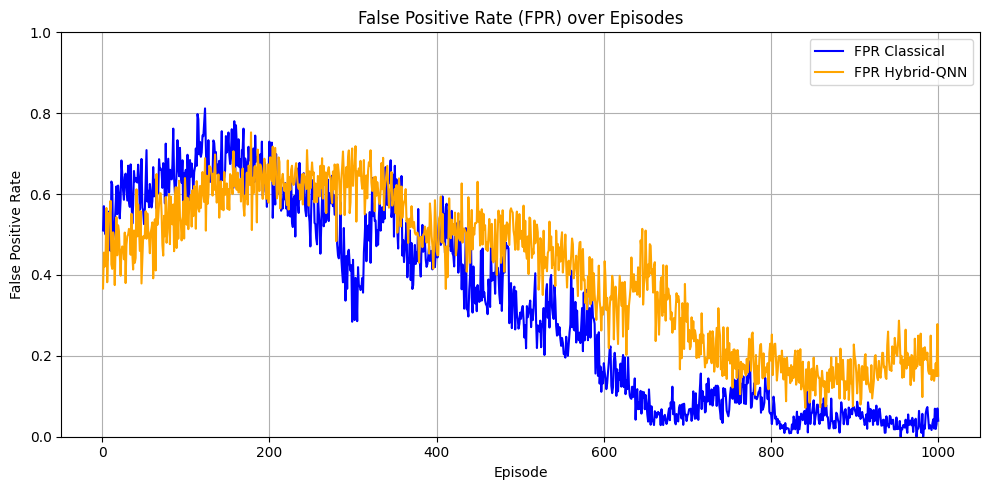

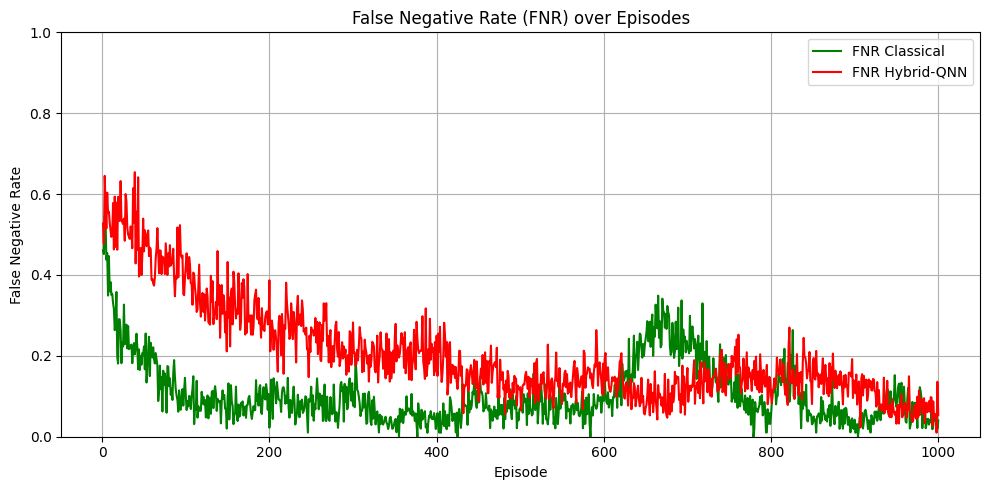

✅ FPR/FNR curves plotted and saved to output directory.


In [ ]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# 1️⃣ Load the results file
# =====================
OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/cicids2017_Results/IQPEmbedding/DDOS/IQP-pca8-DDos/"
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)

metrics_classical = results.get("metrics_classical", [])
metrics_hybrid = results.get("metrics_hybrid", [])

print(f"Loaded {len(metrics_classical)} classical episodes and {len(metrics_hybrid)} hybrid episodes.")

# =====================
# 2️⃣ Compute FPR & FNR for each episode
# =====================
def compute_fpr_fnr(metrics):
    fpr_list, fnr_list = [], []
    for i, m in enumerate(metrics):
        #print(f"Processing episode {i+1}/{len(metrics)}")
        #print("i:", i,"m:",m)
        cm = m.get("confusion_matrix")
        if cm is None or len(cm) != 2:
            fpr_list.append(None)
            fnr_list.append(None)
            continue
        tn, fp, fn, tp = cm.ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        fpr_list.append(fpr)
        fnr_list.append(fnr)
        # Optionally, update the dictionary
        #m["false_positive_rate"] = fpr
        #m["false_negative_rate"] = fnr
    return fpr_list, fnr_list

fpr_classical, fnr_classical = compute_fpr_fnr(metrics_classical)
fpr_hybrid, fnr_hybrid = compute_fpr_fnr(metrics_hybrid)

# =====================
# 3️⃣ Save to CSV
# =====================
df = pd.DataFrame({
    "Episode": range(1, len(fpr_classical) + 1),
    "FPR_Classical": fpr_classical,
    "FNR_Classical": fnr_classical,
    "FPR_Hybrid": fpr_hybrid[:len(fpr_classical)] if metrics_hybrid else None,
    "FNR_Hybrid": fnr_hybrid[:len(fnr_classical)] if metrics_hybrid else None
})

csv_path = os.path.join(OUTPUT_DIR, "fpr_fnr_per_episode.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Saved FPR/FNR per episode to: {csv_path}")

# =====================
# 4️⃣ Plot FPR & FNR curves
# =====================
plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FPR_Classical"], label="FPR Classical", color="blue")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FPR_Hybrid"], label="FPR Hybrid-QNN", color="orange")
plt.title("False Positive Rate (FPR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Positive Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fpr_curve.png"))
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FNR_Classical"], label="FNR Classical", color="green")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FNR_Hybrid"], label="FNR Hybrid-QNN", color="red")
plt.title("False Negative Rate (FNR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Negative Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fnr_curve.png"))
plt.show()

print("✅ FPR/FNR curves plotted and saved to output directory.")


# **PCA 10**

In [ ]:
# -------------------------
# Config / Hyperparameters
# -------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

N_SAMPLES = 45000
ORIG_DIMS = 30
N_QUBITS = 10
N_ACTIONS = 2  # 0 = ignore (benign), 1 = alert (attack)
EPISODE_LENGTH = 200
TRAIN_EPISODES = 1000
GAMMA = 0.99
LR = 1e-3
N_LAYERS_QNN = 2  # ansatz depth for QNN

OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/cicids2017_Results/IQPEmbedding/IQP-pca10-DDos/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
if __name__ == "__main__":
    main()

Data shapes: (25000, 68) (25000,) Attack ratio: 0.50008
PCA shape: (25000, 10)
Train: (20000, 10), Test: (5000, 10)
Training classical REINFORCE baseline...
[Classical] Episode 1/1000  Reward: 70.00  Acc: 0.505  F1: 0.476  Time: 0.36s
[Classical] Episode 10/1000  Reward: 82.00  Acc: 0.475  F1: 0.507  Time: 0.18s
[Classical] Episode 20/1000  Reward: 123.50  Acc: 0.525  F1: 0.541  Time: 0.21s
[Classical] Episode 30/1000  Reward: 150.00  Acc: 0.590  F1: 0.653  Time: 0.21s
[Classical] Episode 40/1000  Reward: 168.50  Acc: 0.615  F1: 0.664  Time: 0.28s
[Classical] Episode 50/1000  Reward: 90.00  Acc: 0.485  F1: 0.558  Time: 0.20s
[Classical] Episode 60/1000  Reward: 188.50  Acc: 0.640  F1: 0.702  Time: 0.21s
[Classical] Episode 70/1000  Reward: 182.50  Acc: 0.625  F1: 0.694  Time: 0.18s
[Classical] Episode 80/1000  Reward: 191.00  Acc: 0.630  F1: 0.675  Time: 0.18s
[Classical] Episode 90/1000  Reward: 206.50  Acc: 0.655  F1: 0.736  Time: 0.18s
[Classical] Episode 100/1000  Reward: 205.50  A

In [1]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# 1️⃣ Load the results file
# =====================
OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/cicids2017_Results/IQPEmbedding/DDOS/IQP-pca10-DDos/"
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)

metrics_classical = results.get("metrics_classical", [])
metrics_hybrid = results.get("metrics_hybrid", [])

print(f"Loaded {len(metrics_classical)} classical episodes and {len(metrics_hybrid)} hybrid episodes.")

# =====================
# 2️⃣ Compute FPR & FNR for each episode
# =====================
def compute_fpr_fnr(metrics):
    fpr_list, fnr_list = [], []
    for i, m in enumerate(metrics):
        #print(f"Processing episode {i+1}/{len(metrics)}")
        #print("i:", i,"m:",m)
        cm = m.get("confusion_matrix")
        if cm is None or len(cm) != 2:
            fpr_list.append(None)
            fnr_list.append(None)
            continue
        tn, fp, fn, tp = cm.ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        fpr_list.append(fpr)
        fnr_list.append(fnr)
        # Optionally, update the dictionary
        #m["false_positive_rate"] = fpr
        #m["false_negative_rate"] = fnr
    return fpr_list, fnr_list

fpr_classical, fnr_classical = compute_fpr_fnr(metrics_classical)
fpr_hybrid, fnr_hybrid = compute_fpr_fnr(metrics_hybrid)

# =====================
# 3️⃣ Save to CSV
# =====================
df = pd.DataFrame({
    "Episode": range(1, len(fpr_classical) + 1),
    "FPR_Classical": fpr_classical,
    "FNR_Classical": fnr_classical,
    "FPR_Hybrid": fpr_hybrid[:len(fpr_classical)] if metrics_hybrid else None,
    "FNR_Hybrid": fnr_hybrid[:len(fnr_classical)] if metrics_hybrid else None
})

csv_path = os.path.join(OUTPUT_DIR, "fpr_fnr_per_episode.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Saved FPR/FNR per episode to: {csv_path}")

# =====================
# 4️⃣ Plot FPR & FNR curves
# =====================
plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FPR_Classical"], label="FPR Classical", color="blue")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FPR_Hybrid"], label="FPR Hybrid-QNN", color="orange")
plt.title("False Positive Rate (FPR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Positive Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fpr_curve.png"))
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FNR_Classical"], label="FNR Classical", color="green")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FNR_Hybrid"], label="FNR Hybrid-QNN", color="red")
plt.title("False Negative Rate (FNR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Negative Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fnr_curve.png"))
plt.show()

print("✅ FPR/FNR curves plotted and saved to output directory.")


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/phd3/outputs/cicids2017_Results/IQPEmbedding/DDOS/IQP-pca10-DDos/qrl_ids_results.pkl'

# **Results**

In [ ]:
import pandas as pd

df_classical = pd.DataFrame(results["metrics_classical"])
df_hybrid = pd.DataFrame(results["metrics_hybrid"])

print(df_classical.head())


   accuracy  precision    recall        f1      confusion_matrix
0     0.525   0.578431  0.531532  0.553991  [[46, 43], [52, 59]]
1     0.470   0.485981  0.504854  0.495238  [[42, 55], [51, 52]]
2     0.495   0.461538  0.446809  0.454054  [[57, 49], [52, 42]]
3     0.500   0.556701  0.486486  0.519231  [[46, 43], [57, 54]]
4     0.565   0.584158  0.567308  0.575610  [[54, 42], [45, 59]]


In [ ]:
last_classical = df_classical.iloc[-1]
last_hybrid = df_hybrid.iloc[-1]

summary = pd.DataFrame({
    "Classical": last_classical,
    "Hybrid QRL": last_hybrid
})
print(summary)


                             Classical            Hybrid QRL
accuracy                          0.94                 0.915
precision                      0.91129               0.87931
recall                        0.991228              0.971429
f1                             0.94958              0.923077
confusion_matrix  [[75, 11], [1, 113]]  [[81, 14], [3, 102]]


In [ ]:
import pickle
import matplotlib.pyplot as plt
import os

# Path to your saved file
OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/IQP-pca8/"
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)

# Access the test results
test_classical = results.get("test_classical", {})
test_hybrid = results.get("test_hybrid", {})

print("=== Keys in test_classical ===")
print(list(test_classical.keys()))

print("\n=== Keys in test_hybrid ===")
print(list(test_hybrid.keys()))


=== Keys in test_classical ===
['accuracy', 'precision', 'recall', 'f1', 'false_negative_rate', 'false_positive_rate', 'confusion_matrix']

=== Keys in test_hybrid ===
['accuracy', 'precision', 'recall', 'f1', 'false_negative_rate', 'false_positive_rate', 'confusion_matrix']


In [ ]:

print("Classical FPR:", test_classical["false_positive_rate"])
print("Classical FNR:", test_classical["false_negative_rate"])
print("Hybrid FPR:", test_hybrid["false_positive_rate"])
print("Hybrid FNR:", test_hybrid["false_negative_rate"])


Classical FPR: 0.16475095785440613
Classical FNR: 0.04907063197026022
Hybrid FPR: 0.17028522775649213
Hybrid FNR: 0.03308550185873606
